# 13 — Efectos geográficos en OLS (`v2`)

Esta notebook estudia si queda estructura geográfica residual después de controlar por las variables observables del modelo `core`.

La pregunta no es solamente si los `fixed effects` geográficos suben el `R²`. La pregunta más importante es:

> ¿Qué estructura geográfica queda en los residuales del modelo, a qué escala aparece, y cómo se comporta cuando agregamos `fixed effects` de región y aglomerado?

Experimentos comparados:

1. `ols_core`
2. `ols_core_region_fe`
3. `ols_core_aglo_fe`
4. `ols_core_aglo_plus_time_fe`

La lógica científica de esta notebook es jerárquica:

```text
Región       = escala geográfica gruesa
Aglomerado  = escala geográfica fina
Tiempo      = controles aditivos adicionales
```

Si los `fixed effects` están funcionando como esperamos, deberían ocurrir tres cosas:

1. `Region FE` debería limpiar casi toda la media residual por región.
2. `Aglomerado FE` debería limpiar la media residual por aglomerado y, por anidamiento, también gran parte de la estructura regional.
3. `Aglomerado + tiempo FE` debería mejorar el ajuste temporal, pero no debería reordenar sustancialmente el patrón geográfico residual.

La notebook evita figuras de pocos números. Las métricas agregadas van en tablas; las figuras se reservan para mostrar mecanismos: estructura residual, observado vs esperado, colapso hacia la diagonal y estabilidad del patrón geográfico.


## 00. Setup y descubrimiento de runs


In [1]:
from pathlib import Path
import json
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"

OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "ols_geographic_effects_v2"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)

print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text())


def read_yaml_if_exists(path: Path):
    if not path.exists():
        return None
    return yaml.safe_load(path.read_text())


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()


RUN_PATTERNS = {
    "ols_core": "ols_core_*",
    "ols_core_region_fe": "ols_core_region_fe_*",
    "ols_core_aglo_fe": "ols_core_aglo_fe_*",
    "ols_core_aglo_plus_time_fe": "ols_core_aglo_plus_time_fe_*",
}

ORDER = [
    "ols_core",
    "ols_core_region_fe",
    "ols_core_aglo_fe",
    "ols_core_aglo_plus_time_fe",
]

DISPLAY_LABELS = {
    "ols_core": "Core OLS",
    "ols_core_region_fe": "+ Región FE",
    "ols_core_aglo_fe": "+ Aglomerado FE",
    "ols_core_aglo_plus_time_fe": "+ Aglomerado + tiempo FE",
}

# Etiquetas de aglomerado.
# Se usan para interpretación y figuras; no alteran los datos ni los modelos.
AGLO_LABELS = {
    0: ("NOTAPPLICABLE", "No aplica"),
    2: ("Gran La Plata", "La Plata"),
    3: ("Bahía Blanca – Cerri", "Bahía Blanca"),
    4: ("Gran Rosario", "Rosario"),
    5: ("Gran Santa Fe", "Santa Fe"),
    6: ("Gran Paraná", "Paraná"),
    7: ("Posadas", "Posadas"),
    8: ("Gran Resistencia", "Resistencia"),
    9: ("Gral. Rivadavia – Rada Tilly", "Comodoro/Rada Tilly"),
    10: ("Gran Mendoza", "Mendoza"),
    12: ("Corrientes", "Corrientes"),
    13: ("Gran Córdoba", "Córdoba"),
    14: ("Concordia", "Concordia"),
    15: ("Formosa", "Formosa"),
    17: ("Neuquén – Plottier", "Neuquén"),
    18: ("Sgo. del Estero – La Banda", "Sgo. del Estero"),
    19: ("Jujuy – Palpalá", "Jujuy-Palpalá"),
    20: ("Río Gallegos", "Río Gallegos"),
    22: ("Gran Catamarca", "Catamarca"),
    23: ("Salta", "Salta"),
    25: ("La Rioja", "La Rioja"),
    26: ("San Luis – El Chorrillo", "San Luis"),
    27: ("Gran San Juan", "San Juan"),
    29: ("Gran Tucumán – T. Viejo", "Tucumán"),
    30: ("Santa Rosa – Toay", "Santa Rosa-Toay"),
    31: ("Ushuaia – Río Grande", "Ushuaia-Río Grande"),
    32: ("Ciudad de Buenos Aires", "CABA"),
    33: ("Partidos del GBA", "GBA"),
    34: ("Mar del Plata – Batán", "Mar del Plata"),
    36: ("Río Cuarto", "Río Cuarto"),
    38: ("San Nicolás – Villa Constitución", "San Nicolás-V. Const."),
    91: ("Rawson – Trelew", "Rawson-Trelew"),
    93: ("Viedma – Carmen de Patagones", "Viedma-C. Patagones"),
    99: ("MISSING", "Missing"),
}

AGLO_LABELS_DF = pd.DataFrame(
    [
        {"AGLOMERADO": str(code), "aglo_name": full, "aglo_label": short}
        for code, (full, short) in AGLO_LABELS.items()
    ]
)

EXCLUDE_AGLO_CODES = {"0", "99"}


def discover_runs() -> dict[str, Path | None]:
    runs = {}
    for experiment, pattern in RUN_PATTERNS.items():
        candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
        if not candidates:
            runs[experiment] = None
            continue

        # Evita colisiones con patrones amplios usando el id del config.
        exact = []
        for candidate in candidates:
            config = read_yaml_if_exists(candidate / "config_used.yaml") or {}
            experiment_id = ((config.get("experiment") or {}).get("id"))
            if experiment_id == experiment:
                exact.append(candidate)

        candidates = exact or candidates
        runs[experiment] = candidates[-1]

    return runs


RUNS = discover_runs()
for experiment, run_dir in RUNS.items():
    print(f"{experiment:32s}", run_dir)


ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/ols_geographic_effects_v2
ols_core                         /home/matias/repos/income-modeling-eph/reports/runs/ols_core_20260611T050750Z
ols_core_region_fe               /home/matias/repos/income-modeling-eph/reports/runs/ols_core_region_fe_20260611T050854Z
ols_core_aglo_fe                 /home/matias/repos/income-modeling-eph/reports/runs/ols_core_aglo_fe_20260611T050907Z
ols_core_aglo_plus_time_fe       /home/matias/repos/income-modeling-eph/reports/runs/ols_core_aglo_plus_time_fe_20260611T050921Z


## 01. Carga de artifacts del backend

La notebook consume predicciones ya producidas por el backend. No refitea modelos.

Este diseño mantiene separadas dos tareas:

- backend: producir predicciones, métricas y artifacts reproducibles;
- notebook: leer artifacts, diagnosticar estructura y construir evidencia interpretativa.


In [2]:
def load_model_comparison(run_dir: Path, experiment: str) -> pd.DataFrame:
    df = read_csv_if_exists(run_dir / "metrics" / "model_comparison.csv")
    if df.empty:
        return df
    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    return df


def load_predictions(run_dir: Path, experiment: str, split: str) -> pd.DataFrame:
    path = run_dir / "predictions" / f"{split}_predictions.parquet"
    df = read_parquet_if_exists(path)
    if df.empty:
        return df

    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    df["split"] = split

    if "residual" not in df.columns:
        df["residual"] = df["y_true"] - df["y_pred"]
    if "abs_error" not in df.columns:
        df["abs_error"] = df["residual"].abs()
    if "squared_error" not in df.columns:
        df["squared_error"] = df["residual"] ** 2

    return df


def load_run_metadata(run_dir: Path, experiment: str) -> dict:
    feature_columns = read_json_if_exists(run_dir / "feature_columns.json") or []
    dataset_card = read_json_if_exists(run_dir / "dataset_card.json") or {}
    config_used = read_yaml_if_exists(run_dir / "config_used.yaml") or {}
    feature_view = config_used.get("feature_view") or {}
    fixed_effects = (config_used.get("model_design") or {}).get("fixed_effects") or []

    return {
        "experiment": experiment,
        "run_dir": str(run_dir),
        "n_feature_columns": len(feature_columns),
        "feature_view_name": feature_view.get("name"),
        "include_blocks": feature_view.get("include_blocks"),
        "fixed_effects_config": fixed_effects,
    }


model_comparison_parts = []
prediction_parts = []
metadata_rows = []

for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    model_comparison_parts.append(load_model_comparison(run_dir, experiment))
    for split in ["validation", "test"]:
        prediction_parts.append(load_predictions(run_dir, experiment, split))
    metadata_rows.append(load_run_metadata(run_dir, experiment))

model_comparison = (
    pd.concat([d for d in model_comparison_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in model_comparison_parts)
    else pd.DataFrame()
)

predictions = (
    pd.concat([d for d in prediction_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in prediction_parts)
    else pd.DataFrame()
)

run_metadata = pd.DataFrame(metadata_rows)
run_metadata["experiment_order"] = run_metadata["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
run_metadata["label"] = run_metadata["experiment"].map(DISPLAY_LABELS)
run_metadata = run_metadata.sort_values("experiment_order").reset_index(drop=True)

if predictions.empty:
    raise RuntimeError(
        "No se cargaron predicciones. Corré primero los experimentos OLS geográficos o revisá RUN_PATTERNS."
    )

print("Predictions:", predictions.shape)
display(run_metadata[["experiment", "label", "n_feature_columns", "feature_view_name", "fixed_effects_config"]])


Predictions: (240000, 12)


,experiment,label,n_feature_columns,feature_view_name,fixed_effects_config
0,ols_core,Core OLS,28,linear_core,[]
1,ols_core_region_fe,+ Región FE,29,linear_core_region_fe,"[{'name': 'region_fe', 'columns': ['Region'], ..."
2,ols_core_aglo_fe,+ Aglomerado FE,29,linear_core_aglo_fe,"[{'name': 'aglo_fe', 'columns': ['AGLOMERADO']..."
3,ols_core_aglo_plus_time_fe,+ Aglomerado + tiempo FE,31,linear_core_aglo_plus_time_fe,"[{'name': 'aglo_fe', 'columns': ['AGLOMERADO']..."


## 02. Enriquecimiento con geografía y tiempo


In [3]:
geo_cols = ["row_id", "Region", "AGLOMERADO", "ANO4", "TRIMESTRE"]

if DATASET_PATH.exists():
    dataset_geo = pd.read_parquet(DATASET_PATH, columns=geo_cols)
else:
    raise FileNotFoundError(f"No se encontró el dataset procesado: {DATASET_PATH}")

pred_geo = predictions.merge(dataset_geo, on="row_id", how="left", validate="many_to_one")

for col in ["Region", "AGLOMERADO", "ANO4", "TRIMESTRE"]:
    pred_geo[col] = pred_geo[col].astype("string")

# Normalizamos código de aglomerado para poder mergear etiquetas.
pred_geo["AGLOMERADO"] = (
    pd.to_numeric(pred_geo["AGLOMERADO"], errors="coerce")
    .astype("Int64")
    .astype("string")
)

pred_geo["aglo_valid"] = (
    pred_geo["AGLOMERADO"].notna()
    & ~pred_geo["AGLOMERADO"].isin(EXCLUDE_AGLO_CODES)
)

pred_geo = pred_geo.merge(AGLO_LABELS_DF, on="AGLOMERADO", how="left")
pred_geo["aglo_label"] = pred_geo["aglo_label"].fillna(pred_geo["AGLOMERADO"])
pred_geo["aglo_name"] = pred_geo["aglo_name"].fillna(pred_geo["AGLOMERADO"])

display(pred_geo[["row_id", "experiment", "split", "Region", "AGLOMERADO", "aglo_label", "ANO4", "TRIMESTRE", "y_true", "y_pred", "residual"]].head())


,row_id,experiment,split,Region,AGLOMERADO,aglo_label,ANO4,TRIMESTRE,y_true,y_pred,residual
0,0,ols_core,validation,Noroeste,23,Salta,2022,3,3.484442,3.554492,-0.070050
1,26,ols_core,validation,Noroeste,0,No aplica,2022,4,3.735759,3.783123,-0.047365
2,32,ols_core,validation,Gran Buenos Aires,33,GBA,2022,1,3.680789,3.504383,0.176406
3,36,ols_core,validation,Pampeana,13,Córdoba,2022,1,3.525822,3.553849,-0.028027
4,56,ols_core,validation,Noreste,8,Resistencia,2022,1,3.856850,3.697136,0.159713


## 03. Tabla principal de performance geográfica

Esta tabla reemplaza el barplot de `ΔR²`.

La mejora predictiva global es importante como contexto, pero no es la figura principal de la notebook. El valor científico central está en cómo los `fixed effects` limpian estructura residual de grupo.


In [4]:
def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return np.nan
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def aggregate_metrics(g):
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    residual = y - yhat
    sd_y = y.std()
    sd_yhat = yhat.std()
    return pd.Series({
        "n": len(g),
        "r2": safe_r2(y, yhat),
        "mae": residual.abs().mean(),
        "rmse": np.sqrt((residual ** 2).mean()),
        "mean_residual": residual.mean(),
        "sd_y_true": sd_y,
        "sd_y_pred": sd_yhat,
        "compression_ratio": sd_yhat / sd_y if sd_y else np.nan,
    })


metrics_by_split = (
    pred_geo
    .groupby(["experiment", "split"])
    .apply(aggregate_metrics)
    .reset_index()
)

metrics_by_split["experiment_order"] = metrics_by_split["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
metrics_by_split["label"] = metrics_by_split["experiment"].map(DISPLAY_LABELS)

validation_summary = (
    metrics_by_split
    .query("split == 'validation'")
    .sort_values("experiment_order")
    .reset_index(drop=True)
)

core_row = validation_summary.query("experiment == 'ols_core'")
if core_row.empty:
    raise RuntimeError("No se encontró ols_core en validation_summary.")
core_row = core_row.iloc[0]

for col in ["r2", "mae", "rmse", "compression_ratio"]:
    validation_summary[f"delta_{col}_vs_core"] = validation_summary[col] - core_row[col]

performance_table = validation_summary[[
    "experiment", "label", "n",
    "r2", "delta_r2_vs_core",
    "mae", "delta_mae_vs_core",
    "rmse", "delta_rmse_vs_core",
    "compression_ratio", "delta_compression_ratio_vs_core",
]].copy()

metrics_by_split.to_csv(TABLE_DIR / "T1_ols_geo_metrics_by_split.csv", index=False)
performance_table.to_csv(TABLE_DIR / "T2_ols_geo_validation_vs_core.csv", index=False)
run_metadata.to_csv(TABLE_DIR / "T3_ols_geo_run_metadata.csv", index=False)

display(performance_table.round(5))


,experiment,label,n,r2,delta_r2_vs_core,mae,delta_mae_vs_core,rmse,delta_rmse_vs_core,compression_ratio,delta_compression_ratio_vs_core
0,ols_core,Core OLS,20000.0,0.40193,0.00000,0.21663,0.00000,0.29189,0.00000,0.62909,0.00000
1,ols_core_region_fe,+ Región FE,20000.0,0.41309,0.01116,0.21427,-0.00236,0.28915,-0.00274,0.63901,0.00992
2,ols_core_aglo_fe,+ Aglomerado FE,20000.0,0.41547,0.01354,0.21370,-0.00293,0.28857,-0.00332,0.64175,0.01267
3,ols_core_aglo_plus_time_fe,+ Aglomerado + tiempo FE,20000.0,0.42288,0.02095,0.21235,-0.00428,0.28673,-0.00516,0.64701,0.01792


**Lectura esperada.** Si la tabla es coherente con las corridas previas, `Aglomerado FE` debería aportar más que `Región FE`, pero ambos efectos deberían ser modestos frente a los bloques fuertes de educación y trabajo. `Aglomerado + tiempo FE` debería mejorar más que `Aglomerado FE`, pero esa mejora adicional corresponde a señal temporal aditiva, no a una reinterpretación de la geografía.


## 04. Residuales medios por grupo

Para el modelo sin `fixed effects` geográficos, el residual medio de un grupo puede leerse como:

\[
ar u_g = \overline{y - \hat y}_g
\]

es decir:

\[
	ext{ingreso observado promedio del grupo}
-
	ext{ingreso esperado promedio según observables}
\]

Esta es la intuición que vuelve interpretables los `fixed effects`: no son medias brutas de ingreso, sino correcciones residuales después de controlar por covariables.


In [5]:
def group_residual_summary(df: pd.DataFrame, group_col: str, *, valid_aglo_only: bool = False) -> pd.DataFrame:
    d = df.copy()
    if valid_aglo_only and group_col == "AGLOMERADO":
        d = d.query("aglo_valid").copy()

    out = (
        d
        .dropna(subset=[group_col])
        .groupby(["experiment", "split", group_col], as_index=False)
        .agg(
            n=("row_id", "size"),
            mean_y_true=("y_true", "mean"),
            mean_y_pred=("y_pred", "mean"),
            mean_residual=("residual", "mean"),
            sd_residual=("residual", "std"),
            mae=("abs_error", "mean"),
            rmse=("squared_error", lambda s: np.sqrt(np.mean(s))),
        )
        .rename(columns={group_col: "group_value"})
        .assign(group_type=group_col)
    )
    out["abs_mean_residual"] = out["mean_residual"].abs()
    return out


region_residual_summary = group_residual_summary(pred_geo, "Region")
aglo_residual_summary = group_residual_summary(pred_geo, "AGLOMERADO", valid_aglo_only=True)

group_residuals = pd.concat([region_residual_summary, aglo_residual_summary], ignore_index=True)

# Etiquetas para aglomerado.
group_residuals = group_residuals.merge(
    AGLO_LABELS_DF.rename(columns={"AGLOMERADO": "group_value"}),
    on="group_value",
    how="left"
)
group_residuals["group_label"] = np.where(
    group_residuals["group_type"].eq("AGLOMERADO"),
    group_residuals["aglo_label"].fillna(group_residuals["group_value"]),
    group_residuals["group_value"],
)

group_residuals.to_csv(TABLE_DIR / "T4_ols_geo_group_residuals.csv", index=False)

display(
    group_residuals
    .query("split == 'validation' and group_type == 'AGLOMERADO'")
    .head()
)


,experiment,split,group_value,n,mean_y_true,mean_y_pred,mean_residual,sd_residual,mae,rmse,group_type,abs_mean_residual,aglo_name,aglo_label,group_label
80,ols_core,validation,10,736,3.625449,3.653867,-0.028419,0.295428,0.216203,0.296592,AGLOMERADO,0.028419,Gran Mendoza,Mendoza,Mendoza
81,ols_core,validation,12,526,3.546887,3.586834,-0.039946,0.315101,0.232664,0.317325,AGLOMERADO,0.039946,Corrientes,Corrientes,Corrientes
82,ols_core,validation,13,1054,3.676712,3.670994,0.005717,0.282697,0.207242,0.282621,AGLOMERADO,0.005717,Gran Córdoba,Córdoba,Córdoba
83,ols_core,validation,14,475,3.558304,3.567844,-0.009540,0.266331,0.198079,0.266221,AGLOMERADO,0.009540,Concordia,Concordia,Concordia
84,ols_core,validation,15,565,3.555446,3.555015,0.000431,0.257728,0.196804,0.257500,AGLOMERADO,0.000431,Formosa,Formosa,Formosa


## 05. Descomposición de varianza residual geográfica

Esta tabla mide cuánta varianza total de `y` está asociada a las medias residuales por grupo.

No es una descomposición causal. Es un diagnóstico de estructura residual:

\[

rac{\mathrm{Var}(ar u_{g(i)})}{\mathrm{Var}(y_i)}
\]

donde \(ar u_{g(i)}\) es el residual medio del grupo al que pertenece la observación \(i\).


In [6]:
def weighted_var(x, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        mask = np.isfinite(x)
        return float(np.nanvar(x[mask])) if mask.any() else np.nan
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w)
    if mask.sum() == 0 or w[mask].sum() == 0:
        return np.nan
    mu = np.average(x[mask], weights=w[mask])
    return float(np.average((x[mask] - mu) ** 2, weights=w[mask]))


rows = []
for (experiment, split, group_type), df_g in group_residuals.groupby(["experiment", "split", "group_type"]):
    df_obs = pred_geo.query("experiment == @experiment and split == @split").copy()

    # Usamos aglomerados reales para la escala AGLOMERADO.
    if group_type == "AGLOMERADO":
        df_obs = df_obs.query("aglo_valid").copy()

    if group_type not in df_obs.columns:
        continue

    effect_map = df_g.set_index("group_value")["mean_residual"]
    df_obs["group_mean_residual"] = df_obs[group_type].map(effect_map)

    var_y = weighted_var(df_obs["y_true"])
    var_pred = weighted_var(df_obs["y_pred"])
    var_resid = weighted_var(df_obs["residual"])
    var_group = weighted_var(df_obs["group_mean_residual"])

    rows.append({
        "experiment": experiment,
        "split": split,
        "group_type": group_type,
        "var_y": var_y,
        "var_pred": var_pred,
        "var_residual": var_resid,
        "var_group_mean_residual": var_group,
        "sd_y": np.sqrt(var_y),
        "sd_residual": np.sqrt(var_resid),
        "sd_group_mean_residual": np.sqrt(var_group),
        "share_var_y": var_group / var_y if var_y else np.nan,
        "share_var_residual": var_group / var_resid if var_resid else np.nan,
        "share_var_y_pct": 100 * var_group / var_y if var_y else np.nan,
        "share_var_residual_pct": 100 * var_group / var_resid if var_resid else np.nan,
    })

geo_variance_decomposition = pd.DataFrame(rows)
geo_variance_decomposition["experiment_order"] = geo_variance_decomposition["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
geo_variance_decomposition["label"] = geo_variance_decomposition["experiment"].map(DISPLAY_LABELS)
geo_variance_decomposition["group_label"] = geo_variance_decomposition["group_type"].map({
    "Region": "Región",
    "AGLOMERADO": "Aglomerado",
})

geo_variance_decomposition.to_csv(TABLE_DIR / "T5_ols_geo_variance_decomposition.csv", index=False)

variance_table = (
    geo_variance_decomposition
    .query("split == 'validation'")
    .pivot_table(
        index="label",
        columns="group_label",
        values="share_var_y_pct",
        aggfunc="first"
    )
    .reindex([DISPLAY_LABELS[e] for e in ORDER])
    [["Región", "Aglomerado"]]
)

variance_table.to_csv(TABLE_DIR / "T6_ols_geo_variance_matrix.csv")

display(variance_table.round(4))


group_label,Región,Aglomerado
label,,
Core OLS,0.8609,1.2259
+ Región FE,0.0151,0.4182
+ Aglomerado FE,0.0090,0.0911
+ Aglomerado + tiempo FE,0.0097,0.0928


## 06. Figura 1 — matriz de limpieza residual geográfica

Esta figura reemplaza el lineplot de varianza residual.

La matriz muestra el mecanismo jerárquico:

- `Core OLS` deja estructura residual por región y aglomerado.
- `Región FE` limpia la escala regional, pero deja heterogeneidad entre aglomerados.
- `Aglomerado FE` limpia la escala fina y, por lo tanto, también casi toda la escala regional.
- Agregar tiempo encima de aglomerado no debería cambiar demasiado la estructura geográfica residual restante.


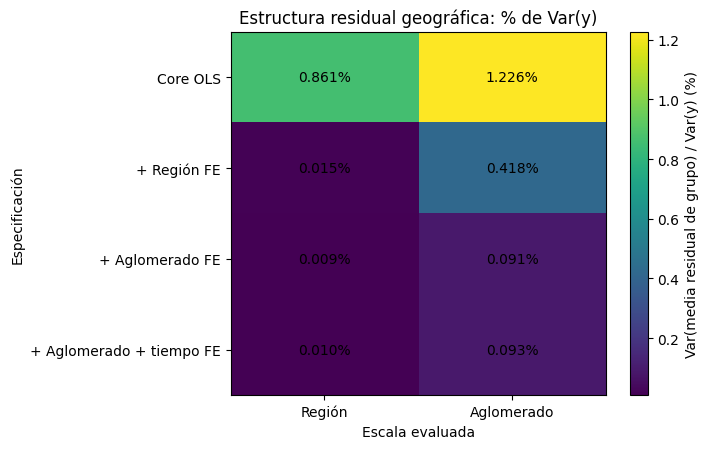

In [7]:
mat = variance_table.copy()

fig, ax = plt.subplots(figsize=(7.2, 4.6))
im = ax.imshow(mat.values, aspect="auto")

ax.set_xticks(np.arange(mat.shape[1]))
ax.set_xticklabels(mat.columns)
ax.set_yticks(np.arange(mat.shape[0]))
ax.set_yticklabels(mat.index)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        value = mat.iloc[i, j]
        ax.text(j, i, f"{value:.3f}%", ha="center", va="center")

ax.set_title("Estructura residual geográfica: % de Var(y)")
ax.set_xlabel("Escala evaluada")
ax.set_ylabel("Especificación")
fig.colorbar(im, ax=ax, label="Var(media residual de grupo) / Var(y) (%)")
fig.tight_layout()
fig.savefig(FIG_DIR / "F1_v2_geo_residual_cleanup_matrix.png", dpi=180)
plt.show()


## 07. Aglomerados extremos: top/bottom 3 por especificación

Antes de graficar todos los puntos, conviene mirar una tabla pequeña de casos extremos.

La tabla no debe leerse como ranking bruto de ciudades ricas o pobres. Es un ranking de residuales medios ajustados:

\[
ar y_g - \overline{\hat y}_g
\]

- valor positivo: el modelo subpredice el ingreso medio del aglomerado;
- valor negativo: el modelo sobrepredice el ingreso medio del aglomerado.


In [8]:
SPLIT = "validation"
MIN_N = 50

df_aglo = (
    group_residuals
    .query("split == @SPLIT and group_type == 'AGLOMERADO' and n >= @MIN_N")
    .copy()
)

main_aglo_experiments = [
    "ols_core",
    "ols_core_aglo_fe",
    "ols_core_aglo_plus_time_fe",
]

extreme_parts = []
for exp in main_aglo_experiments:
    d = df_aglo.query("experiment == @exp").copy()
    if d.empty:
        continue

    bottom = d.nsmallest(3, "mean_residual").assign(extremo="bottom 3")
    top = d.nlargest(3, "mean_residual").assign(extremo="top 3")

    extreme_parts.append(pd.concat([bottom, top], ignore_index=True))

aglo_extremes = (
    pd.concat(extreme_parts, ignore_index=True)
    if extreme_parts else pd.DataFrame()
)

if not aglo_extremes.empty:
    aglo_extremes["modelo"] = aglo_extremes["experiment"].map(DISPLAY_LABELS)
    aglo_extremes = aglo_extremes[[
        "modelo", "extremo", "group_value", "group_label", "n",
        "mean_y_true", "mean_y_pred", "mean_residual", "abs_mean_residual",
    ]].sort_values(["modelo", "extremo", "mean_residual"])

    aglo_extremes.to_csv(TABLE_DIR / "T7_v2_aglo_top_bottom3_residuals.csv", index=False)
    display(aglo_extremes.round(5))
else:
    print("No se pudieron construir extremos por aglomerado.")


,modelo,extremo,group_value,group_label,n,mean_y_true,mean_y_pred,mean_residual,abs_mean_residual
12,+ Aglomerado + tiempo FE,bottom 3,31,Ushuaia-Río Grande,389,3.87483,3.90944,-0.03461,0.03461
13,+ Aglomerado + tiempo FE,bottom 3,91,Rawson-Trelew,458,3.71331,3.74141,-0.02810,0.02810
14,+ Aglomerado + tiempo FE,bottom 3,6,Paraná,483,3.64707,3.67302,-0.02595,0.02595
17,+ Aglomerado + tiempo FE,top 3,2,La Plata,385,3.67266,3.66304,0.00962,0.00962
16,+ Aglomerado + tiempo FE,top 3,93,Viedma-C. Patagones,397,3.75246,3.73869,0.01377,0.01377
15,+ Aglomerado + tiempo FE,top 3,3,Bahía Blanca,358,3.72001,3.68967,0.03034,0.03034
6,+ Aglomerado FE,bottom 3,31,Ushuaia-Río Grande,389,3.87483,3.91060,-0.03577,0.03577
7,+ Aglomerado FE,bottom 3,91,Rawson-Trelew,458,3.71331,3.74471,-0.03140,0.03140
8,+ Aglomerado FE,bottom 3,36,Río Cuarto,428,3.65665,3.68115,-0.02450,0.02450
11,+ Aglomerado FE,top 3,29,Tucumán,933,3.55156,3.54150,0.01006,0.01006


## 08. Figura 2 — observado vs esperado por aglomerado

Esta figura reemplaza el scatter de ingreso medio vs residual.

La versión más limpia es:

\[
x = \overline{\hat y}_g
\qquad
y = ar y_g
\]

La línea de 45° representa calibración perfecta a nivel de aglomerado. La distancia vertical a esa línea es exactamente el residual medio del grupo.

Esta figura conecta con la intuición de compresión vista antes: en lugar de mirar individuos en las colas de ingreso, miramos grupos cuyo ingreso observado queda por encima o por debajo de lo que el modelo espera según sus observables.


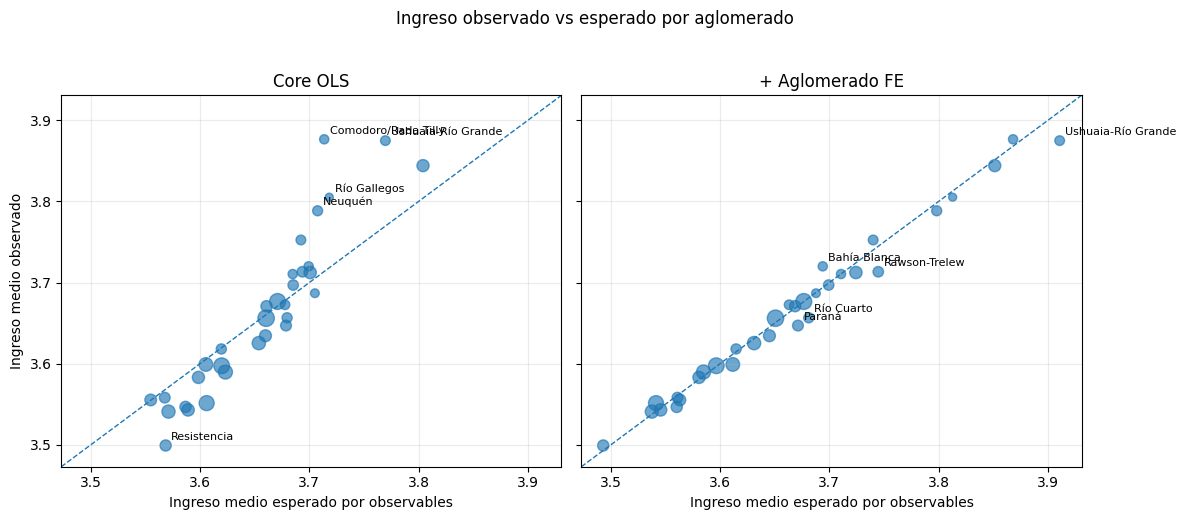

In [9]:
def annotate_extremes(ax, tmp, n_labels=4):
    if tmp.empty:
        return
    labels = tmp.nlargest(n_labels, "abs_mean_residual")
    for _, row in labels.iterrows():
        ax.annotate(
            str(row["group_label"]),
            (row["mean_y_pred"], row["mean_y_true"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )


plot_experiments = ["ols_core", "ols_core_aglo_fe"]
plot_df = df_aglo.query("experiment in @plot_experiments").copy()

x_min = plot_df[["mean_y_pred", "mean_y_true"]].min().min()
x_max = plot_df[["mean_y_pred", "mean_y_true"]].max().max()
pad = 0.02
lim = (x_min - pad, x_max + pad)

fig, axes = plt.subplots(1, len(plot_experiments), figsize=(12, 5), sharex=True, sharey=True)

if len(plot_experiments) == 1:
    axes = [axes]

for ax, exp in zip(axes, plot_experiments):
    tmp = plot_df.query("experiment == @exp").copy()

    ax.scatter(
        tmp["mean_y_pred"],
        tmp["mean_y_true"],
        s=np.clip(tmp["n"] / 8, 16, 140),
        alpha=0.65,
    )
    ax.plot(lim, lim, linestyle="--", linewidth=1)
    annotate_extremes(ax, tmp, n_labels=5)

    ax.set_title(DISPLAY_LABELS.get(exp, exp))
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("Ingreso medio esperado por observables")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Ingreso medio observado")
fig.suptitle("Ingreso observado vs esperado por aglomerado", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "F2_v2_aglo_observed_vs_expected.png", dpi=180, bbox_inches="tight")
plt.show()


## 09. Figura 3 — ranking sobrio de residuales por aglomerado

El gráfico anterior muestra la diagonal. Este gráfico muestra directamente los residuales.

Seleccionamos los aglomerados con residuales más extremos en `Core OLS` y comparamos qué ocurre al agregar `Aglomerado FE` y `Aglomerado + tiempo FE`.

No se unen puntos con líneas: los aglomerados son categorías discretas, no una serie temporal.


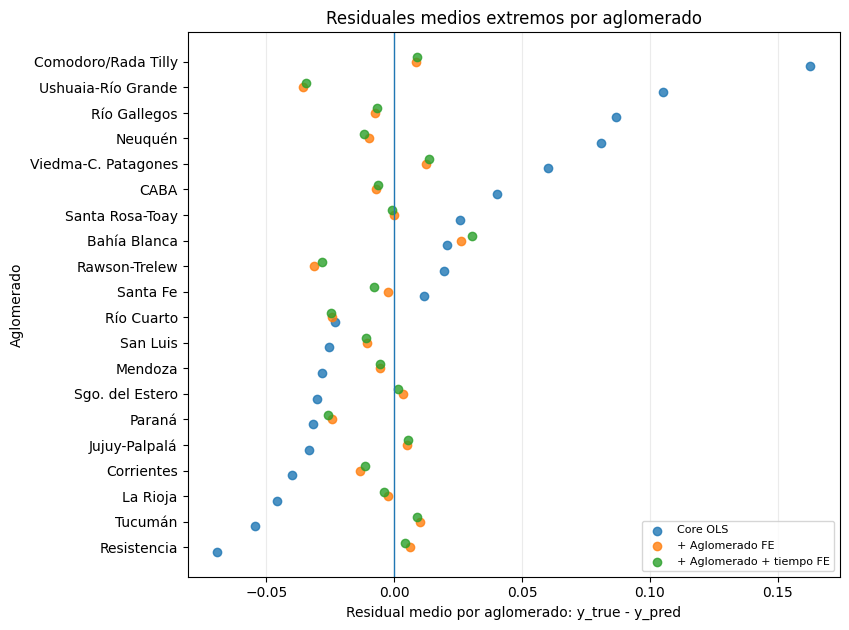

In [10]:
REFERENCE_EXPERIMENT = "ols_core"
N_EACH_SIDE = 10

core_aglo = df_aglo.query("experiment == @REFERENCE_EXPERIMENT").copy()
selected_groups = pd.concat([
    core_aglo.nsmallest(N_EACH_SIDE, "mean_residual"),
    core_aglo.nlargest(N_EACH_SIDE, "mean_residual"),
], ignore_index=True)["group_value"].drop_duplicates().tolist()

order_df = (
    core_aglo
    .query("group_value in @selected_groups")
    .sort_values("mean_residual")
    [["group_value", "group_label", "mean_residual"]]
    .reset_index(drop=True)
)

plot_df = (
    df_aglo
    .query("group_value in @selected_groups and experiment in @main_aglo_experiments")
    .merge(order_df[["group_value"]].assign(y_pos=np.arange(len(order_df))), on="group_value", how="left")
    .copy()
)

offsets = {
    "ols_core": -0.18,
    "ols_core_aglo_fe": 0.00,
    "ols_core_aglo_plus_time_fe": 0.18,
}

fig, ax = plt.subplots(figsize=(8.6, max(5.5, 0.32 * len(order_df))))

for exp in main_aglo_experiments:
    tmp = plot_df.query("experiment == @exp").copy()
    if tmp.empty:
        continue
    ax.scatter(
        tmp["mean_residual"],
        tmp["y_pos"] + offsets.get(exp, 0),
        s=36,
        alpha=0.8,
        label=DISPLAY_LABELS.get(exp, exp),
    )

ax.axvline(0, linewidth=1)
ax.set_yticks(np.arange(len(order_df)))
ax.set_yticklabels(order_df["group_label"])
ax.set_xlabel("Residual medio por aglomerado: y_true - y_pred")
ax.set_ylabel("Aglomerado")
ax.set_title("Residuales medios extremos por aglomerado")
ax.grid(axis="x", alpha=0.25)
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(FIG_DIR / "F3_v2_aglo_residual_extremes_dotplot.png", dpi=180)
plt.show()


## 10. Figura 4 — colapso hacia cero al agregar `Aglomerado FE`

Esta figura muestra el mecanismo de los `fixed effects` desde otra perspectiva.

Si `Aglomerado FE` está haciendo su trabajo, los aglomerados con residuales medios grandes en `Core OLS` deberían acercarse a cero cuando el modelo incluye el efecto fijo de aglomerado.

Esto no significa que desaparece todo el error individual. Significa que desaparece casi toda la media residual sistemática del grupo.


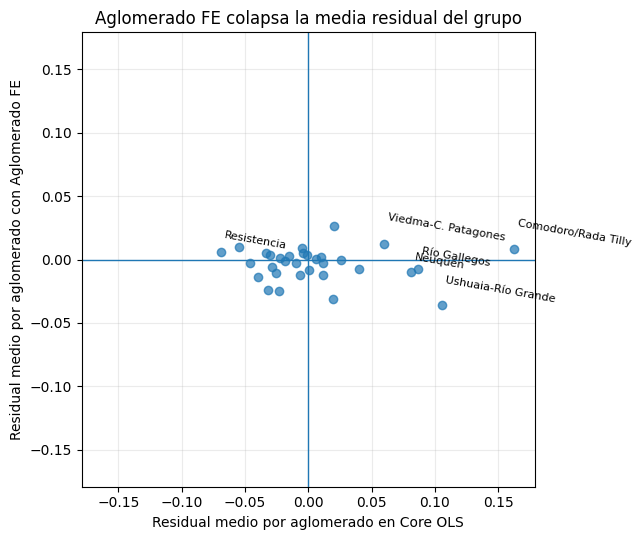

In [20]:
df_resid_wide = (
    df_aglo
    .query("experiment in @main_aglo_experiments")
    .pivot_table(
        index=["group_value", "group_label"],
        columns="experiment",
        values="mean_residual",
        aggfunc="first",
    )
    .reset_index()
)

if {"ols_core", "ols_core_aglo_fe"}.issubset(df_resid_wide.columns):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))

    ax.scatter(
        df_resid_wide["ols_core"],
        df_resid_wide["ols_core_aglo_fe"],
        alpha=0.7,
    )

    x_lim = np.nanmax(np.abs(df_resid_wide["ols_core"].to_numpy()))
    y_lim = np.nanmax(np.abs(df_resid_wide["ols_core_aglo_fe"].to_numpy()))
    lim_x = (-x_lim * 1.1, x_lim * 1.1)
    # lim_y = (-max(y_lim * 1.4, 0.01), max(y_lim * 1.4, 0.01))
    lim_y = lim_x

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(lim_x)
    ax.set_ylim(lim_y)

    # Etiquetamos los casos más extremos en Core.
    lab = df_resid_wide.assign(abs_core=lambda d: d["ols_core"].abs()).nlargest(6, "abs_core")
    for _, row in lab.iterrows():
        ax.annotate(
            str(row["group_label"]),
            (row["ols_core"], row["ols_core_aglo_fe"]),
            xytext=(2, 2),
            textcoords="offset points",
            fontsize=8,
            rotation=-10,
        )

    ax.set_title("Aglomerado FE colapsa la media residual del grupo")
    ax.set_xlabel("Residual medio por aglomerado en Core OLS")
    ax.set_ylabel("Residual medio por aglomerado con Aglomerado FE")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "F4_v2_core_vs_aglo_fe_residual_collapse.png", dpi=180)
    plt.show()
else:
    print("No están disponibles las columnas necesarias para el scatter Core vs Aglomerado FE.")


## 11. Chequeo de fondo: estabilidad al agregar tiempo

El heatmap de correlaciones de la versión anterior se reemplaza por dos salidas más económicas:

1. una tabla de correlaciones;
2. un scatter de `Aglomerado FE` vs `Aglomerado + tiempo FE`.

El scatter puede ser útil como chequeo de background: si los puntos caen sobre la diagonal, agregar tiempo no cambia sustancialmente el patrón residual geográfico restante.


experiment,ols_core,ols_core_aglo_fe,ols_core_aglo_plus_time_fe
experiment,,,
ols_core,1.0000,-0.0914,-0.0649
ols_core_aglo_fe,-0.0914,1.0000,0.9902
ols_core_aglo_plus_time_fe,-0.0649,0.9902,1.0000


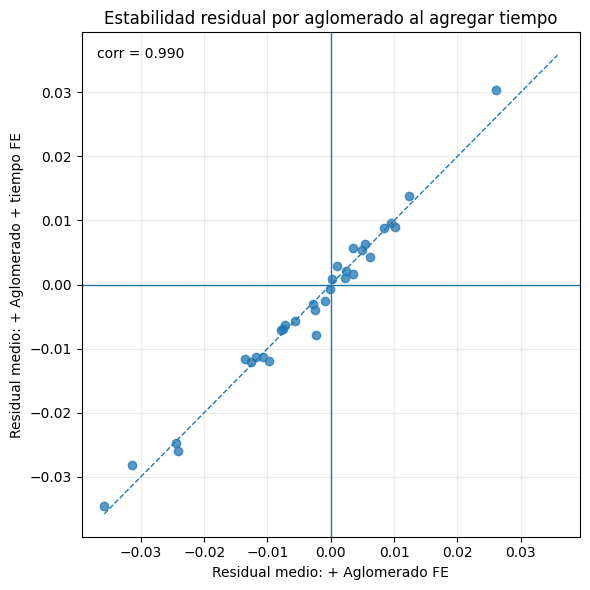

In [12]:
df_fe_wide = (
    df_aglo
    .query("experiment in @main_aglo_experiments")
    .pivot_table(
        index="group_value",
        columns="experiment",
        values="mean_residual",
        aggfunc="first",
    )
)

# Preserve el orden por residual core cuando sea posible.
if "ols_core" in df_fe_wide.columns:
    df_fe_wide = df_fe_wide.reindex(
        df_fe_wide.sort_values("ols_core").index
    )

fe_corr = df_fe_wide.corr()
fe_corr.to_csv(TABLE_DIR / "T8_v2_aglo_residual_correlation.csv")

display(fe_corr.round(4))

if {"ols_core_aglo_fe", "ols_core_aglo_plus_time_fe"}.issubset(df_fe_wide.columns):
    fig, ax = plt.subplots(figsize=(6, 6))

    x = df_fe_wide["ols_core_aglo_fe"]
    y = df_fe_wide["ols_core_aglo_plus_time_fe"]

    ax.scatter(x, y, alpha=0.75)
    lim = np.nanmax(np.abs(pd.concat([x, y]).to_numpy()))
    lim = max(lim, 0.01)
    ax.plot([-lim, lim], [-lim, lim], linestyle="--", linewidth=1)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    corr_value = x.corr(y)
    ax.text(
        0.03, 0.97,
        f"corr = {corr_value:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )

    ax.set_title("Estabilidad residual por aglomerado al agregar tiempo")
    ax.set_xlabel("Residual medio: + Aglomerado FE")
    ax.set_ylabel("Residual medio: + Aglomerado + tiempo FE")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "F5_v2_aglo_fe_vs_aglo_time_fe_background_check.png", dpi=180)
    plt.show()
else:
    print("No están disponibles las columnas necesarias para comparar Aglo FE vs Aglo + tiempo FE.")


## 12. Contributors: peso muestral × residual²

Los residuales extremos no siempre son los mayores contribuyentes a la varianza residual agregada. Un aglomerado puede contribuir mucho porque tiene un residual grande, porque tiene muchas observaciones, o por ambas razones.

Esta tabla ayuda a separar magnitud y peso.


In [13]:
df_contrib = df_aglo.copy()
df_contrib["weight"] = df_contrib["n"] / df_contrib.groupby("experiment")["n"].transform("sum")
df_contrib["variance_contribution"] = df_contrib["weight"] * (df_contrib["mean_residual"] ** 2)

top_contributors = (
    df_contrib
    .sort_values(["experiment", "variance_contribution"], ascending=[True, False])
    .groupby("experiment")
    .head(12)
    [[
        "experiment",
        "group_value",
        "group_label",
        "n",
        "mean_y_true",
        "mean_y_pred",
        "mean_residual",
        "abs_mean_residual",
        "weight",
        "variance_contribution",
    ]]
    .reset_index(drop=True)
)

top_contributors["modelo"] = top_contributors["experiment"].map(DISPLAY_LABELS)
top_contributors.to_csv(TABLE_DIR / "T9_v2_ols_geo_top_aglo_contributors.csv", index=False)

display(
    top_contributors[[
        "modelo", "group_value", "group_label", "n",
        "mean_y_true", "mean_y_pred", "mean_residual",
        "weight", "variance_contribution",
    ]].round(5)
)


,modelo,group_value,group_label,n,mean_y_true,mean_y_pred,mean_residual,weight,variance_contribution
0,Core OLS,9,Comodoro/Rada Tilly,354,3.87646,3.71364,0.16281,0.01861,0.00049
1,Core OLS,31,Ushuaia-Río Grande,389,3.87483,3.76958,0.10525,0.02044,0.00023
2,Core OLS,29,Tucumán,933,3.55156,3.60616,-0.05460,0.04904,0.00015
3,Core OLS,17,Neuquén,417,3.78843,3.70762,0.08081,0.02192,0.00014
4,Core OLS,8,Resistencia,518,3.49937,3.56866,-0.06929,0.02722,0.00013
5,Core OLS,20,Río Gallegos,269,3.80515,3.71827,0.08688,0.01414,0.00011
6,Core OLS,93,Viedma-C. Patagones,397,3.75246,3.69235,0.06011,0.02087,0.00008
7,Core OLS,25,La Rioja,637,3.54322,3.58917,-0.04595,0.03348,0.00007
8,Core OLS,32,CABA,609,3.84402,3.80398,0.04004,0.03201,0.00005
9,Core OLS,19,Jujuy-Palpalá,826,3.58988,3.62329,-0.03341,0.04341,0.00005


## 13. Resumen diagnóstico automático

Este bloque produce notas compactas para auditar resultados. No reemplaza la interpretación narrativa.


In [14]:
def fmt(x, digits=5):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"


notes = []
summary = validation_summary.set_index("experiment")

for exp in ["ols_core_region_fe", "ols_core_aglo_fe", "ols_core_aglo_plus_time_fe"]:
    if exp in summary.index and "ols_core" in summary.index:
        notes.append(
            f"{DISPLAY_LABELS.get(exp, exp)}: ΔR² vs core = {fmt(summary.loc[exp, 'delta_r2_vs_core'])}; "
            f"ΔMAE = {fmt(summary.loc[exp, 'delta_mae_vs_core'])}; "
            f"ΔRMSE = {fmt(summary.loc[exp, 'delta_rmse_vs_core'])}."
        )

v = geo_variance_decomposition.query("split == 'validation'")
for exp in ORDER:
    for group_type in ["Region", "AGLOMERADO"]:
        row = v.query("experiment == @exp and group_type == @group_type")
        if not row.empty:
            row = row.iloc[0]
            group_label = "Región" if group_type == "Region" else "Aglomerado"
            notes.append(
                f"{DISPLAY_LABELS.get(exp, exp)} / {group_label}: "
                f"sd(media residual de grupo) = {fmt(row['sd_group_mean_residual'])}; "
                f"share Var(y) = {fmt(row['share_var_y_pct'])}%."
            )

if {"ols_core_aglo_fe", "ols_core_aglo_plus_time_fe"}.issubset(fe_corr.columns):
    corr_value = fe_corr.loc["ols_core_aglo_fe", "ols_core_aglo_plus_time_fe"]
    notes.append(
        f"Estabilidad del patrón residual por aglomerado entre Aglo FE y Aglo+tiempo FE: corr = {fmt(corr_value)}."
    )

DIAGNOSTIC_SUMMARY = "\n".join(f"- {note}" for note in notes)
print(DIAGNOSTIC_SUMMARY)

(TABLE_DIR / "T10_v2_ols_geo_diagnostic_notes.txt").write_text(DIAGNOSTIC_SUMMARY, encoding="utf-8")


- + Región FE: ΔR² vs core = 0.01116; ΔMAE = -0.00236; ΔRMSE = -0.00274.
- + Aglomerado FE: ΔR² vs core = 0.01354; ΔMAE = -0.00293; ΔRMSE = -0.00332.
- + Aglomerado + tiempo FE: ΔR² vs core = 0.02095; ΔMAE = -0.00428; ΔRMSE = -0.00516.
- Core OLS / Región: sd(media residual de grupo) = 0.03502; share Var(y) = 0.86093%.
- Core OLS / Aglomerado: sd(media residual de grupo) = 0.04171; share Var(y) = 1.22593%.
- + Región FE / Región: sd(media residual de grupo) = 0.00463; share Var(y) = 0.01505%.
- + Región FE / Aglomerado: sd(media residual de grupo) = 0.02436; share Var(y) = 0.41818%.
- + Aglomerado FE / Región: sd(media residual de grupo) = 0.00359; share Var(y) = 0.00903%.
- + Aglomerado FE / Aglomerado: sd(media residual de grupo) = 0.01137; share Var(y) = 0.09110%.
- + Aglomerado + tiempo FE / Región: sd(media residual de grupo) = 0.00371; share Var(y) = 0.00966%.
- + Aglomerado + tiempo FE / Aglomerado: sd(media residual de grupo) = 0.01148; share Var(y) = 0.09282%.
- Estabilidad de

1080

## 14. Cierre interpretativo

La evidencia de esta notebook debería leerse en dos niveles.

Primero, el aporte predictivo global de la geografía es real pero acotado. Los `fixed effects` geográficos mejoran las métricas, pero no cambian radicalmente el techo predictivo del modelo. Por eso no conviene vender la geografía como determinante dominante del ingreso individual.

Segundo, la geografía sí aparece con claridad en los residuales medios de grupo. El modelo `core` deja diferencias sistemáticas entre aglomerados: algunos tienen ingresos observados por encima de lo esperado según sus observables, otros por debajo. Esto es precisamente lo que los `fixed effects` geográficos corrigen.

La parte más fuerte de la notebook es la confirmación de expectativas teóricas:

1. `Region FE` reduce casi a cero la estructura residual regional.
2. `Aglomerado FE` reduce casi a cero la estructura residual de aglomerado.
3. Como `Aglomerado` es una escala más fina que `Región`, `Aglomerado FE` también absorbe casi toda la estructura regional.
4. La escala gruesa no absorbe toda la escala fina: con `Region FE` todavía puede quedar heterogeneidad entre aglomerados dentro de regiones.
5. Agregar controles temporales aditivos mejora el ajuste, pero no reordena sustancialmente el patrón geográfico residual.

En lenguaje de tesis:

> Los `fixed effects` geográficos funcionan como correcciones locales de medias residuales, no como una explicación causal ni dominante del ingreso. Su valor principal es diagnóstico: revelan una estructura geográfica pequeña pero sistemática que sobrevive a los controles observables y se comporta de manera coherente con la teoría de efectos fijos jerárquicos.


## 15. Outputs escritos

Tablas:

```text
reports/notebook_outputs/ols_geographic_effects_v2/tables/
```

Figuras:

```text
reports/notebook_outputs/ols_geographic_effects_v2/figures/
```

Candidatos principales para tesis:

```text
T2_ols_geo_validation_vs_core.csv
T6_ols_geo_variance_matrix.csv
T7_v2_aglo_top_bottom3_residuals.csv
T9_v2_ols_geo_top_aglo_contributors.csv

F1_v2_geo_residual_cleanup_matrix.png
F2_v2_aglo_observed_vs_expected.png
F3_v2_aglo_residual_extremes_dotplot.png
F4_v2_core_vs_aglo_fe_residual_collapse.png
F5_v2_aglo_fe_vs_aglo_time_fe_background_check.png
```
